**1) Imports**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

**2) Charger les données**

In [3]:
df = pd.read_csv("C:/Users/sabri/Desktop/M1_MLSD/S1/Technologies_conteneurisation/projet-reduction-dimension/Projet_finale/data/city_lifestyle_dataset.csv")
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


**3) Nettoyage**

In [4]:
X = df.drop(columns=["city_name", "country"])

**4) Standardisation**

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
print("Dimensions des données originales :", X.shape)
print("Dimensions après standardisation :", X_scaled.shape)

Dimensions des données originales : (300, 8)
Dimensions après standardisation : (300, 8)


**5) Modèle UMAP (2D)**

In [6]:
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

C:\Users\sabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


**6) Visualisation**

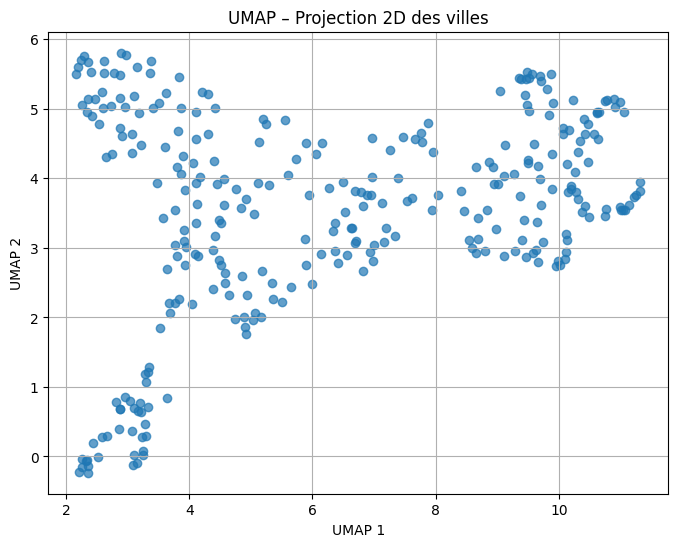

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.7)
plt.title("UMAP – Projection 2D des villes")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

**Observation :**
La projection UMAP met en évidence plusieurs regroupements distincts de villes, suggérant l’existence de structures latentes dans les données. UMAP semble bien préserver les voisinages locaux tout en révélant une organisation globale cohérente. Une analyse complémentaire serait nécessaire pour interpréter la signification socio-économique de ces clusters.

**7) Export**

In [11]:
umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
umap_df.to_csv("C:/Users/sabri/Desktop/M1_MLSD/S1/Technologies_conteneurisation/projet-reduction-dimension/Projet_finale/outputs/umap_emb_2d.csv", index=False)